# Supermarket Sales Analysis

## Project Overview
This notebook analyzes 2,000 supermarket transactions to understand:
- Sales performance by branch, product line, and time period
- Customer behavior and satisfaction patterns
- Peak shopping hours and busy periods
- Payment method preferences
- Relationships between numerical variables

## Dataset
- **Records:** 2,000 transactions
- **Time Period:** 2023
- **Branches:** 3 (A, B, C)
- **Product Lines:** 6 categories

## Objective
Generate actionable business insights and recommendations for operations improvement.

## Business Questions

We will answer these questions through data analysis:

1. **Sales Performance**
   - What is the total sales revenue and average transaction value?
   - Which branch has the highest sales?
   - Which product line generates the most revenue?

2. **Customer Behavior**
   - What is the customer satisfaction (rating) distribution?
   - Do member customers spend more than normal customers?
   - Are there gender differences in purchasing behavior?

3. **Time Patterns**
   - What are the busiest hours of the day?
   - Which days of the week have the most transactions?
   - Are there seasonal trends (monthly variations)?

4. **Payment & Operations**
   - What payment methods are most preferred?
   - How many items do customers typically buy per transaction?
   - Is there a relationship between quantity purchased and rating?

5. **Correlations**
   - Is there a relationship between unit price and quantity purchased?
   - Does tax correlate with total sales?
   - Is there a correlation between rating and transaction value?

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [2]:
# Load the dataset
df = pd.read_csv('../data/raw/supermarket_sales.csv')

# Display basic information
print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)
print(f"\nDataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n" + "=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
print(df.head())

print("\n" + "=" * 60)
print("COLUMN NAMES AND TYPES")
print("=" * 60)
print(df.dtypes)


DATASET LOADED SUCCESSFULLY

Dataset Shape: (2000, 14)
Rows: 2000, Columns: 14

FIRST 5 ROWS
  Invoice_ID Branch       City Customer_Type  Gender         Product_Line  \
0  INV000001      B   Mandalay        Member    Male     Food & Beverages   
1  INV000002      C   Mandalay        Member  Female     Food & Beverages   
2  INV000003      C  Naypyitaw        Normal  Female  Fashion Accessories   
3  INV000004      B  Naypyitaw        Member  Female     Food & Beverages   
4  INV000005      C     Yangon        Normal  Female     Food & Beverages   

   Unit_Price  Quantity   Tax   Total        Date   Time      Payment  Rating  
0       69.36         3  7.28  119.58  2023-08-08  18:54  Credit card     8.4  
1       35.25         1  6.62  137.13  2023-02-09  18:44  Credit card     4.3  
2       57.56         8  4.66  490.48  2023-08-24  16:16         Cash     9.6  
3       16.60         5  8.57  142.54  2023-02-09  11:35         Cash     4.5  
4       49.07         1  3.70   24.43  2023-

## Data Quality Assessment

Before analysis, we check:
- Missing values
- Duplicate records
- Data types appropriateness
- Basic statistical anomalies

In [3]:
# Data Quality Checks
print("=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

print("\n" + "=" * 60)
print("DUPLICATE RECORDS CHECK")
print("=" * 60)
print(f"Total duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate Invoice_IDs: {df.duplicated(subset=['Invoice_ID']).sum()}")

print("\n" + "=" * 60)
print("DATA TYPES SUMMARY")
print("=" * 60)
print(df.info())

MISSING VALUES CHECK
Invoice_ID       0
Branch           0
City             0
Customer_Type    0
Gender           0
Product_Line     0
Unit_Price       0
Quantity         0
Tax              0
Total            0
Date             0
Time             0
Payment          0
Rating           0
dtype: int64

Total missing values: 0

DUPLICATE RECORDS CHECK
Total duplicate rows: 0
Duplicate Invoice_IDs: 0

DATA TYPES SUMMARY
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice_ID     2000 non-null   str    
 1   Branch         2000 non-null   str    
 2   City           2000 non-null   str    
 3   Customer_Type  2000 non-null   str    
 4   Gender         2000 non-null   str    
 5   Product_Line   2000 non-null   str    
 6   Unit_Price     2000 non-null   float64
 7   Quantity       2000 non-null   int64  
 8   Tax            2000 non-null   float64
 

## Feature Engineering

Extract temporal features from Date and Time columns to enable time-based analysis.

In [4]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract temporal features from Date
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Day_of_Week'] = df['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['Day_Name'] = df['Date'].dt.day_name()

# Extract Hour from Time (while it's still a string)
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M').dt.hour

# Create time period categories
def categorize_time(hour):
    if 8 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Time_Period'] = df['Hour'].apply(categorize_time)

# Verify the new features
print("=" * 60)
print("NEW FEATURES CREATED")
print("=" * 60)
print(df[['Date', 'Year', 'Month', 'Day_Name', 'Hour', 'Time_Period']].head(10))

print("\n" + "=" * 60)
print("FEATURE SUMMARY")
print("=" * 60)
print(f"Unique Years: {df['Year'].unique()}")
print(f"Unique Months: {sorted(df['Month'].unique())}")
print(f"Unique Hours: {sorted(df['Hour'].unique())}")
print(f"\nTime Period Distribution:\n{df['Time_Period'].value_counts()}")

NEW FEATURES CREATED
        Date  Year  Month  Day_Name  Hour Time_Period
0 2023-08-08  2023      8   Tuesday    18     Evening
1 2023-02-09  2023      2  Thursday    18     Evening
2 2023-08-24  2023      8  Thursday    16   Afternoon
3 2023-02-09  2023      2  Thursday    11     Morning
4 2023-07-04  2023      7   Tuesday     8     Morning
5 2023-12-18  2023     12    Monday    13   Afternoon
6 2023-10-21  2023     10  Saturday    14   Afternoon
7 2023-09-04  2023      9    Monday    11     Morning
8 2023-03-30  2023      3  Thursday     9     Morning
9 2023-08-05  2023      8  Saturday    18     Evening

FEATURE SUMMARY
Unique Years: [2023]
Unique Months: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
Unique Hours: [np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.in

In [5]:
# Quantify the time period analysis
print("=" * 60)
print("TIME PERIOD ANALYSIS")
print("=" * 60)

time_period_stats = df['Time_Period'].value_counts().sort_values(ascending=False)
time_period_pct = (df['Time_Period'].value_counts(normalize=True) * 100).sort_values(ascending=False)

for period in time_period_stats.index:
    count = time_period_stats[period]
    pct = time_period_pct[period]
    print(f"{period:12} : {count:4} transactions ({pct:.1f}%)")

print("\n" + "=" * 60)
print("KEY INSIGHT")
print("=" * 60)
afternoon_pct = time_period_pct['Afternoon']
morning_pct = time_period_pct['Morning']
difference = afternoon_pct - morning_pct

print(f"Afternoon has {difference:.1f}% more transactions than Morning")
print(f"Afternoon accounts for nearly 43% of all daily transactions")

TIME PERIOD ANALYSIS
Afternoon    :  844 transactions (42.2%)
Morning      :  649 transactions (32.5%)
Evening      :  507 transactions (25.4%)

KEY INSIGHT
Afternoon has 9.7% more transactions than Morning
Afternoon accounts for nearly 43% of all daily transactions


## Initial Time-Based Insights

### Observation
The supermarket experiences uneven traffic throughout the day:
- **Afternoon (12-5 PM):** 844 transactions (42.2%) - Peak period
- **Morning (8 AM-12 PM):** 649 transactions (32.5%)
- **Evening (5-9 PM):** 507 transactions (25.4%) - Slowest period

### Business Recommendations

1. **Staffing Optimization**
   - Increase staff during afternoon peak (12-5 PM)
   - Reduce/schedule breaks during evening (5-9 PM)
   - This reduces labor costs while maintaining service quality

2. **Inventory Management**
   - Stock high-demand items before noon to prepare for afternoon rush
   - Plan restocking during evening when traffic is lower

3. **Checkout Operations**
   - Open more checkout counters during afternoon
   - Can reduce checkouts in evening to save costs

4. **Promotional Strategy**
   - Run major promotions during afternoon peak to maximize visibility
   - Evening promotions could help drive traffic during slow hours

## Sales Performance Analysis

Analyzing revenue generation across branches, product lines, and customer segments to identify key revenue drivers.

In [6]:
# Basic sales metrics
print("=" * 60)
print("OVERALL SALES METRICS")
print("=" * 60)
print(f"Total Revenue: ₹{df['Total'].sum():,.2f}")
print(f"Average Transaction Value: ₹{df['Total'].mean():.2f}")
print(f"Median Transaction Value: ₹{df['Total'].median():.2f}")
print(f"Minimum Transaction: ₹{df['Total'].min():.2f}")
print(f"Maximum Transaction: ₹{df['Total'].max():.2f}")

print("\n" + "=" * 60)
print("SALES BY BRANCH")
print("=" * 60)
branch_sales = df.groupby('Branch').agg({
    'Total': ['sum', 'count', 'mean'],
    'Invoice_ID': 'count'
}).round(2)

branch_sales.columns = ['Total Revenue', 'Transactions', 'Avg Transaction', 'Count']
print(branch_sales)

print("\n" + "=" * 60)
print("SALES BY PRODUCT LINE")
print("=" * 60)
product_sales = df.groupby('Product_Line').agg({
    'Total': ['sum', 'count', 'mean'],
    'Quantity': 'sum'
}).round(2)

product_sales.columns = ['Total Revenue', 'Transactions', 'Avg Transaction', 'Total Qty']
print(product_sales.sort_values('Total Revenue', ascending=False))

OVERALL SALES METRICS
Total Revenue: ₹519,280.69
Average Transaction Value: ₹259.64
Median Transaction Value: ₹258.04
Minimum Transaction: ₹20.37
Maximum Transaction: ₹499.91

SALES BY BRANCH
        Total Revenue  Transactions  Avg Transaction  Count
Branch                                                     
A           179047.93           674           265.65    674
B           180821.79           696           259.80    696
C           159410.97           630           253.03    630

SALES BY PRODUCT LINE
                        Total Revenue  Transactions  Avg Transaction  \
Product_Line                                                           
Health & Beauty              96970.32           363           267.14   
Sports & Travel              91177.89           351           259.77   
Electronic Accessories       88995.19           337           264.08   
Home & Lifestyle             86351.63           335           257.77   
Food & Beverages             78233.94           312  

In [7]:
# Quantify branch differences
branch_revenue = df.groupby('Branch')['Total'].sum().sort_values(ascending=False)
print("=" * 60)
print("BRANCH PERFORMANCE - QUANTIFIED")
print("=" * 60)
for i, (branch, revenue) in enumerate(branch_revenue.items(), 1):
    pct_of_total = (revenue / df['Total'].sum()) * 100
    print(f"{i}. Branch {branch}: ₹{revenue:,.2f} ({pct_of_total:.1f}% of total)")

# Quantify product line differences
product_revenue = df.groupby('Product_Line')['Total'].sum().sort_values(ascending=False)
print("\n" + "=" * 60)
print("PRODUCT LINE PERFORMANCE - RANKED")
print("=" * 60)
for i, (product, revenue) in enumerate(product_revenue.items(), 1):
    pct_of_total = (revenue / df['Total'].sum()) * 100
    print(f"{i}. {product}: ₹{revenue:,.2f} ({pct_of_total:.1f}%)")

BRANCH PERFORMANCE - QUANTIFIED
1. Branch B: ₹180,821.79 (34.8% of total)
2. Branch A: ₹179,047.93 (34.5% of total)
3. Branch C: ₹159,410.97 (30.7% of total)

PRODUCT LINE PERFORMANCE - RANKED
1. Health & Beauty: ₹96,970.32 (18.7%)
2. Sports & Travel: ₹91,177.89 (17.6%)
3. Electronic Accessories: ₹88,995.19 (17.1%)
4. Home & Lifestyle: ₹86,351.63 (16.6%)
5. Food & Beverages: ₹78,233.94 (15.1%)
6. Fashion Accessories: ₹77,551.72 (14.9%)


## Sales Performance Findings

### Branch Performance Analysis

**Revenue Distribution:**
- Branch B: ₹180,821.79 (34.8%) - Highest performer
- Branch A: ₹179,047.93 (34.5%) - Nearly tied with B
- Branch C: ₹159,410.97 (30.7%) - Underperforming

**Key Observations:**
1. Branches A and B perform almost identically (only 0.3% difference)
2. Branch C lags by 4.1% compared to Branch B
3. This suggests Branch C has lower foot traffic or customer engagement

**Potential Causes for Branch C Underperformance:**
- Lower foot traffic (location, visibility, accessibility)
- Fewer marketing efforts or local awareness
- Store operations or customer service issues
- Demographic differences in customer base

### Product Line Performance Analysis

**Revenue by Product Category:**
1. Health & Beauty: 18.7% (₹96,970)
2. Sports & Travel: 17.6% (₹91,177)
3. Electronic Accessories: 17.1% (₹88,995)
4. Home & Lifestyle: 16.6% (₹86,351)
5. Food & Beverages: 15.1% (₹78,233)
6. Fashion Accessories: 14.9% (₹77,551)

**Key Observation:**
The revenue spread across product lines is relatively balanced (only 3.8% difference between highest and lowest). This indicates:
- **Good product diversity** — customers shop for multiple categories
- **Strong portfolio** — no single category dominates or fails
- **Stable demand** — revenue is not dependent on one product line

### Recommendations

1. **Address Branch C Underperformance**
   - Investigate foot traffic patterns at Branch C
   - Compare location, staffing, and store conditions with A and B
   - Implement targeted local marketing to drive awareness

2. **Leverage Product Diversity**
   - Maintain balanced inventory across all categories
   - Use underperforming Fashion Accessories as opportunity for strategic positioning
   - Cross-promote categories to increase basket size

## Customer Behavior & Satisfaction Analysis

Analyzing customer segments, satisfaction ratings, and purchase patterns to understand what drives satisfaction and revenue.

In [8]:
# Customer Type Analysis
print("=" * 60)
print("CUSTOMER TYPE ANALYSIS")
print("=" * 60)
customer_type = df.groupby('Customer_Type').agg({
    'Total': ['sum', 'count', 'mean'],
    'Rating': 'mean',
    'Quantity': 'mean'
}).round(2)

customer_type.columns = ['Total Revenue', 'Count', 'Avg Transaction', 'Avg Rating', 'Avg Items']
print(customer_type)

# Gender Analysis
print("\n" + "=" * 60)
print("GENDER ANALYSIS")
print("=" * 60)
gender = df.groupby('Gender').agg({
    'Total': ['sum', 'count', 'mean'],
    'Rating': 'mean',
    'Quantity': 'mean'
}).round(2)

gender.columns = ['Total Revenue', 'Count', 'Avg Transaction', 'Avg Rating', 'Avg Items']
print(gender)

# Rating Distribution
print("\n" + "=" * 60)
print("RATING DISTRIBUTION")
print("=" * 60)
rating_stats = df['Rating'].describe().round(2)
print(rating_stats)

print("\nRating Frequency:")
print(df['Rating'].value_counts().sort_index())

CUSTOMER TYPE ANALYSIS
               Total Revenue  Count  Avg Transaction  Avg Rating  Avg Items
Customer_Type                                                              
Member             261919.34   1018           257.29        6.95       5.00
Normal             257361.35    982           262.08        6.97       5.06

GENDER ANALYSIS
        Total Revenue  Count  Avg Transaction  Avg Rating  Avg Items
Gender                                                              
Female      264337.27   1019           259.41        7.03       5.05
Male        254943.42    981           259.88        6.88       5.02

RATING DISTRIBUTION
count    2000.00
mean        6.96
std         1.73
min         4.00
25%         5.40
50%         6.95
75%         8.40
max        10.00
Name: Rating, dtype: float64

Rating Frequency:
Rating
4.0     30
4.1     26
4.2     37
4.3     35
4.4     35
        ..
9.6     34
9.7     32
9.8     31
9.9     22
10.0    20
Name: count, Length: 61, dtype: int64


In [9]:
# Quantify the differences
print("=" * 60)
print("CUSTOMER TYPE - DETAILED COMPARISON")
print("=" * 60)

member_data = df[df['Customer_Type'] == 'Member']
normal_data = df[df['Customer_Type'] == 'Normal']

print(f"Members:")
print(f"  Total Revenue: ₹{member_data['Total'].sum():,.2f}")
print(f"  Transactions: {len(member_data)}")
print(f"  Avg Spend per Transaction: ₹{member_data['Total'].mean():.2f}")
print(f"  Avg Rating: {member_data['Rating'].mean():.2f}")

print(f"\nNormal Customers:")
print(f"  Total Revenue: ₹{normal_data['Total'].sum():,.2f}")
print(f"  Transactions: {len(normal_data)}")
print(f"  Avg Spend per Transaction: ₹{normal_data['Total'].mean():.2f}")
print(f"  Avg Rating: {normal_data['Rating'].mean():.2f}")

# Calculate differences
spend_diff = ((normal_data['Total'].mean() - member_data['Total'].mean()) / member_data['Total'].mean()) * 100
rating_diff = normal_data['Rating'].mean() - member_data['Rating'].mean()

print(f"\nKey Differences:")
print(f"  Normal customers spend {spend_diff:.2f}% MORE per transaction")
print(f"  Rating difference: {rating_diff:.2f} points (negligible)")
print(f"  Members have {len(member_data) - len(normal_data)} more transactions")

CUSTOMER TYPE - DETAILED COMPARISON
Members:
  Total Revenue: ₹261,919.34
  Transactions: 1018
  Avg Spend per Transaction: ₹257.29
  Avg Rating: 6.95

Normal Customers:
  Total Revenue: ₹257,361.35
  Transactions: 982
  Avg Spend per Transaction: ₹262.08
  Avg Rating: 6.97

Key Differences:
  Normal customers spend 1.86% MORE per transaction
  Rating difference: 0.02 points (negligible)
  Members have 36 more transactions


In [10]:
print("=" * 60)
print("GENDER - DETAILED COMPARISON")
print("=" * 60)

female_data = df[df['Gender'] == 'Female']
male_data = df[df['Gender'] == 'Male']

print(f"Female:")
print(f"  Total Revenue: ₹{female_data['Total'].sum():,.2f}")
print(f"  Transactions: {len(female_data)}")
print(f"  Avg Spend per Transaction: ₹{female_data['Total'].mean():.2f}")
print(f"  Avg Rating: {female_data['Rating'].mean():.2f}")

print(f"\nMale:")
print(f"  Total Revenue: ₹{male_data['Total'].sum():,.2f}")
print(f"  Transactions: {len(male_data)}")
print(f"  Avg Spend per Transaction: ₹{male_data['Total'].mean():.2f}")
print(f"  Avg Rating: {male_data['Rating'].mean():.2f}")

# Calculate differences
revenue_diff = ((female_data['Total'].sum() - male_data['Total'].sum()) / male_data['Total'].sum()) * 100
spend_diff = ((female_data['Total'].mean() - male_data['Total'].mean()) / male_data['Total'].mean()) * 100
rating_diff = female_data['Rating'].mean() - male_data['Rating'].mean()

print(f"\nKey Differences:")
print(f"  Female customers generate {revenue_diff:.2f}% MORE total revenue")
print(f"  Spend difference per transaction: {spend_diff:.2f}%")
print(f"  Rating difference: {rating_diff:.2f} points")

GENDER - DETAILED COMPARISON
Female:
  Total Revenue: ₹264,337.27
  Transactions: 1019
  Avg Spend per Transaction: ₹259.41
  Avg Rating: 7.03

Male:
  Total Revenue: ₹254,943.42
  Transactions: 981
  Avg Spend per Transaction: ₹259.88
  Avg Rating: 6.88

Key Differences:
  Female customers generate 3.68% MORE total revenue
  Spend difference per transaction: -0.18%
  Rating difference: 0.14 points


In [11]:
print("=" * 60)
print("RATING DISTRIBUTION - ANALYSIS")
print("=" * 60)

# Categorize ratings
df['Rating_Category'] = pd.cut(df['Rating'], bins=[0, 5, 7, 10], labels=['Low (4-5)', 'Medium (5-7)', 'High (7-10)'])

print("Ratings by Category:")
print(df['Rating_Category'].value_counts().sort_index())

rating_pct = (df['Rating_Category'].value_counts(normalize=True) * 100).sort_index()
print("\nPercentage:")
for cat, pct in rating_pct.items():
    print(f"  {cat}: {pct:.1f}%")

print(f"\nOverall Satisfaction Level:")
print(f"  Mean Rating: {df['Rating'].mean():.2f}/10")
print(f"  Median Rating: {df['Rating'].median():.2f}/10")

RATING DISTRIBUTION - ANALYSIS
Ratings by Category:
Rating_Category
Low (4-5)       374
Medium (5-7)    651
High (7-10)     975
Name: count, dtype: int64

Percentage:
  Low (4-5): 18.7%
  Medium (5-7): 32.6%
  High (7-10): 48.8%

Overall Satisfaction Level:
  Mean Rating: 6.96/10
  Median Rating: 6.95/10


## Customer Behavior & Satisfaction Analysis

### Customer Type Comparison (Members vs Normal)

**Performance Metrics:**
- Members: ₹261,919 (1,018 transactions), Avg: ₹257.29/transaction, Rating: 6.95
- Normal: ₹257,361 (982 transactions), Avg: ₹262.08/transaction, Rating: 6.97

**Key Findings:**
1. **Similar Spending Per Transaction:** Normal customers spend 1.86% more per transaction, but the difference is minimal
2. **Members Drive Volume:** Members contribute more total revenue (₹4,558 more) through higher transaction frequency (36 additional transactions)
3. **Identical Satisfaction:** Rating difference is negligible (0.02 points), indicating both customer types are equally satisfied
4. **Membership Value:** Membership programs succeed through transaction volume, not higher per-transaction spending

**Insight:** The membership program is effective in driving repeat visits, not in increasing spending per visit.

---

### Gender Differences in Purchasing Behavior

**Performance Metrics:**
- Female: ₹264,337 (1,019 transactions), Avg: ₹259.41/transaction, Rating: 7.03
- Male: ₹254,943 (981 transactions), Avg: ₹259.88/transaction, Rating: 6.88

**Key Findings:**
1. **Female Customers Generate More Revenue:** 3.68% higher total revenue despite nearly identical spending per transaction
2. **Transaction Frequency Difference:** Females have 38 more transactions, indicating higher store visit frequency
3. **Higher Female Satisfaction:** Females rate 0.14 points higher (7.03 vs 6.88), suggesting better experience perception
4. **Per-Transaction Spending Parity:** Spending per transaction is nearly identical (0.18% difference), indicating no gender-based product preference differences

**Insight:** Female customers are more engaged with the store (more frequent visits), resulting in higher total revenue and satisfaction.

---

### Overall Customer Satisfaction

**Rating Distribution:**
- High Satisfaction (7-10): 975 transactions (48.8%) ← Nearly half of customers
- Medium Satisfaction (5-7): 651 transactions (32.6%)
- Low Satisfaction (4-5): 374 transactions (18.7%)

**Satisfaction Metrics:**
- Mean Rating: 6.96/10 (Moderate-to-Good)
- Median Rating: 6.95/10 (Consistent with mean)

**Key Findings:**
1. **Majority Satisfied:** Nearly 49% of customers are highly satisfied (rating 7-10)
2. **Consistent Satisfaction:** Mean and median are nearly identical, indicating stable, consistent satisfaction levels
3. **Room for Improvement:** 18.7% of customers give low ratings, representing potential dissatisfaction points
4. **No Major Outliers:** Satisfaction is concentrated in the 5-10 range with no extreme variations

**Insight:** Overall customer satisfaction is moderate-to-good, but the 19% low-satisfaction segment suggests operational or service issues that need investigation.

---

### Recommendations

1. **Strengthen Membership Program**
   - Focus on retention and repeat visits (proven strategy)
   - Target normal customers to convert to membership

2. **Female-Focused Marketing**
   - Female customers show higher engagement and satisfaction
   - Develop targeted marketing to leverage this segment

3. **Address Low-Satisfaction Segment**
   - Investigate why 18.7% of customers give low ratings
   - Identify and fix service/product issues
   - Could significantly improve overall satisfaction if addressed

## Data Visualizations

Visual representations of key findings to support business insights and recommendations.

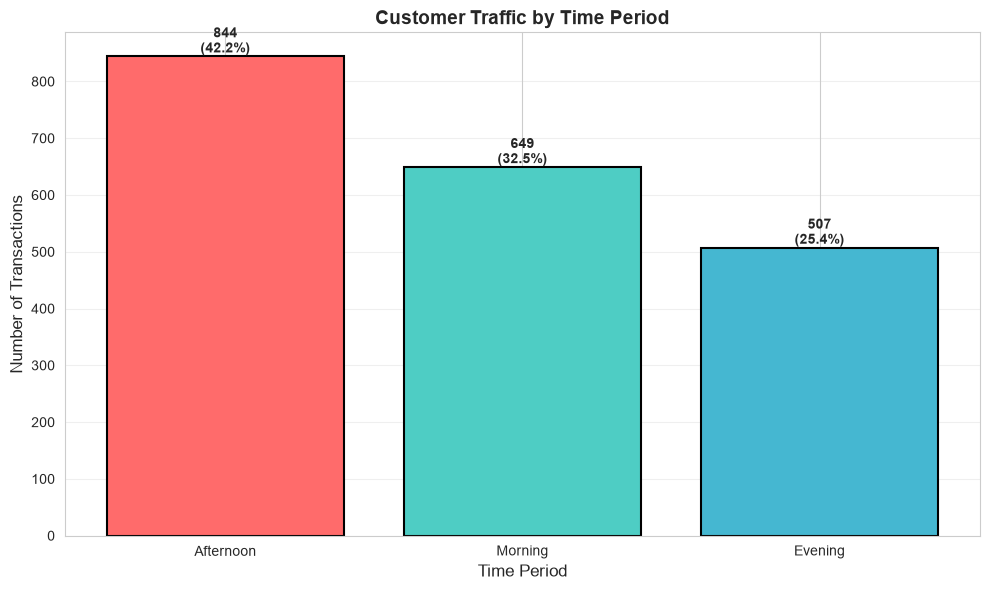

✓ Visualization 1 saved: Time Period Distribution


In [12]:
# 1. Time Period Distribution
plt.figure(figsize=(10, 6))
time_counts = df['Time_Period'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = plt.bar(time_counts.index, time_counts.values, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold')

plt.title('Customer Traffic by Time Period', fontsize=14, fontweight='bold')
plt.xlabel('Time Period', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/01_time_period_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 1 saved: Time Period Distribution")

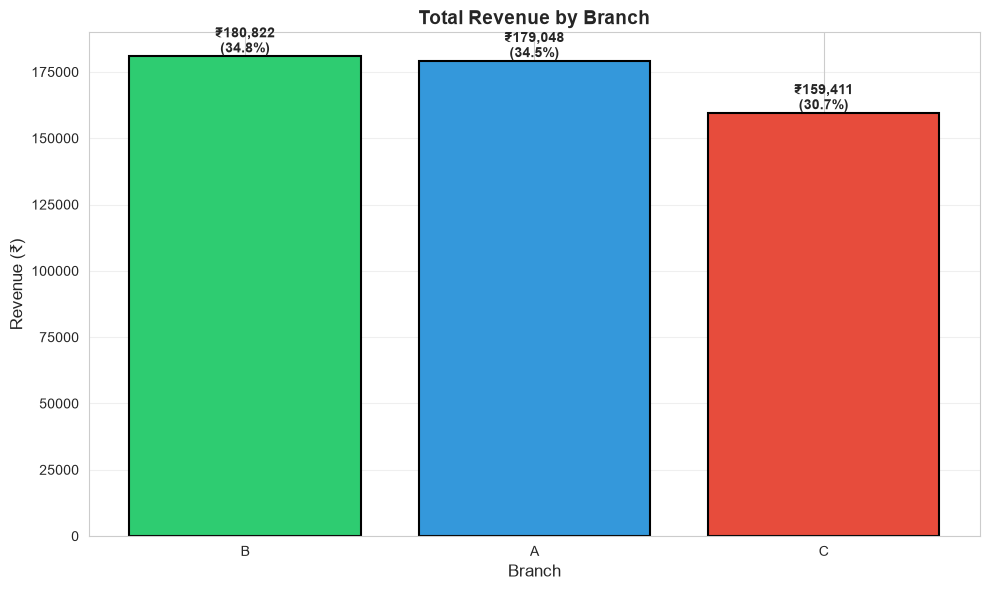

✓ Visualization 2 saved: Branch Performance


In [13]:
# 2. Branch Performance
plt.figure(figsize=(10, 6))
branch_revenue = df.groupby('Branch')['Total'].sum().sort_values(ascending=False)
colors_branch = ['#2ECC71', '#3498DB', '#E74C3C']
bars = plt.bar(branch_revenue.index, branch_revenue.values, color=colors_branch, edgecolor='black', linewidth=1.5)

# Add value labels
for bar in bars:
    height = bar.get_height()
    pct = (height / branch_revenue.sum()) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'₹{height:,.0f}\n({pct:.1f}%)',
             ha='center', va='bottom', fontweight='bold')

plt.title('Total Revenue by Branch', fontsize=14, fontweight='bold')
plt.xlabel('Branch', fontsize=12)
plt.ylabel('Revenue (₹)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/02_branch_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 2 saved: Branch Performance")

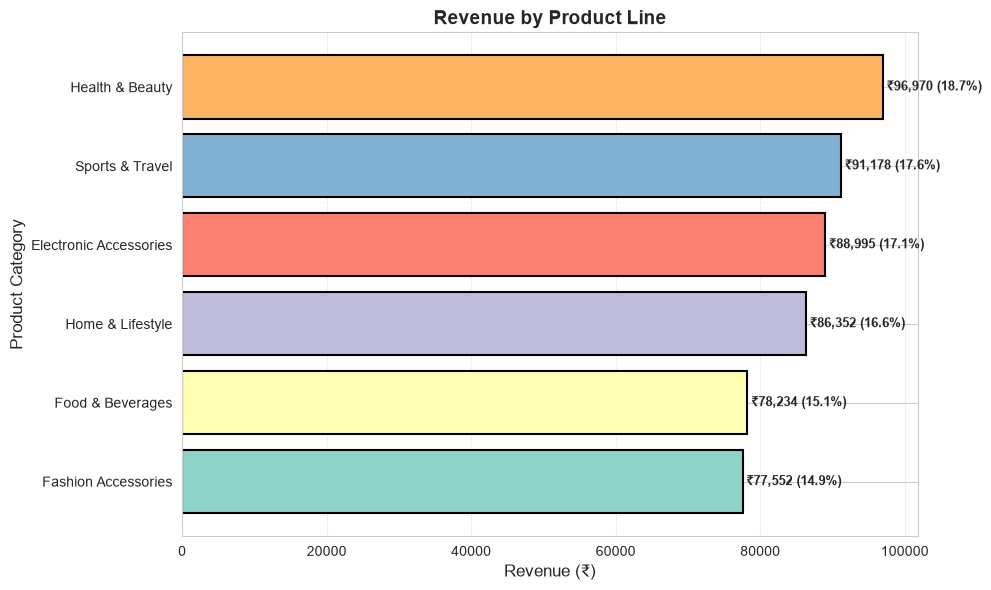

✓ Visualization 3 saved: Product Line Revenue


In [14]:
# 3. Product Line Revenue (Horizontal Bar for better readability)
plt.figure(figsize=(10, 6))
product_revenue = df.groupby('Product_Line')['Total'].sum().sort_values(ascending=True)
colors_product = plt.cm.Set3(range(len(product_revenue)))
bars = plt.barh(product_revenue.index, product_revenue.values, color=colors_product, edgecolor='black', linewidth=1.5)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    pct = (width / product_revenue.sum()) * 100
    plt.text(width, bar.get_y() + bar.get_height()/2.,
             f' ₹{width:,.0f} ({pct:.1f}%)',
             ha='left', va='center', fontweight='bold', fontsize=9)

plt.title('Revenue by Product Line', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (₹)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/03_product_line_revenue.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 3 saved: Product Line Revenue")

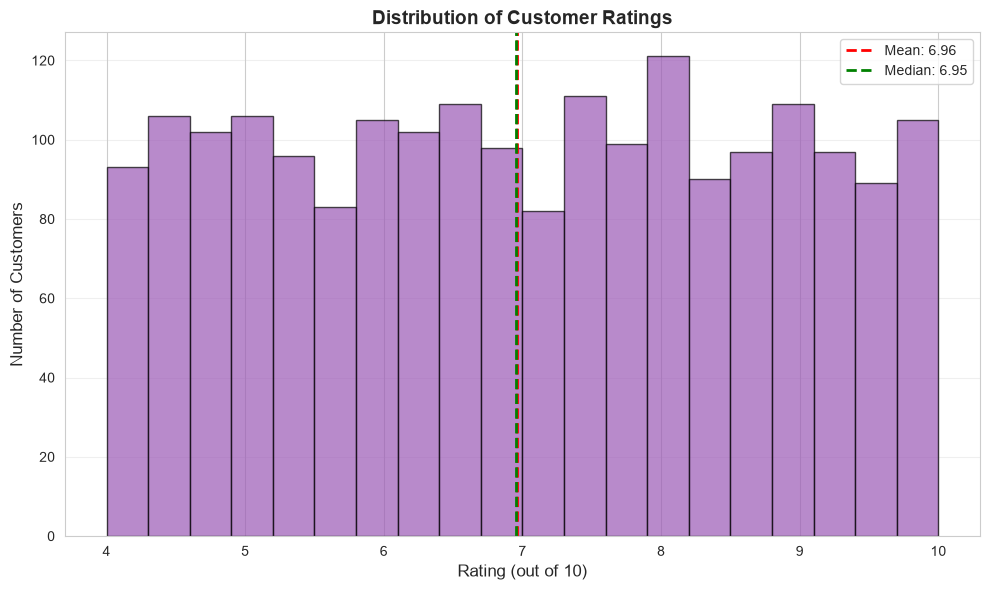

✓ Visualization 4 saved: Rating Distribution


In [15]:
# 4. Rating Distribution (Histogram)
plt.figure(figsize=(10, 6))
plt.hist(df['Rating'], bins=20, color='#9B59B6', edgecolor='black', alpha=0.7)
plt.axvline(df['Rating'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Rating"].mean():.2f}')
plt.axvline(df['Rating'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["Rating"].median():.2f}')

plt.title('Distribution of Customer Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Rating (out of 10)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/04_rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 4 saved: Rating Distribution")

<Figure size 1000x600 with 0 Axes>

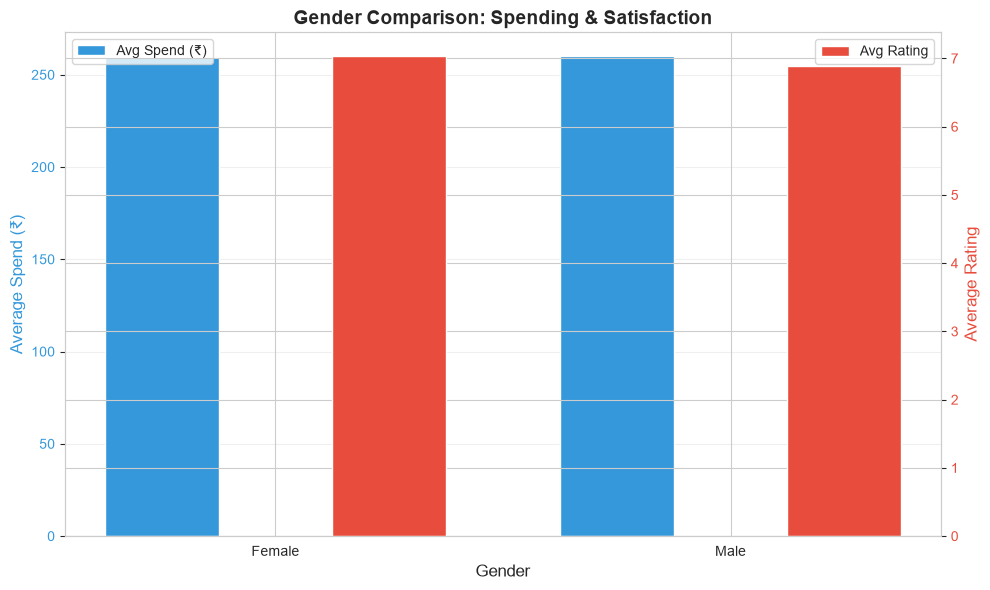

✓ Visualization 5 saved: Gender Comparison


In [16]:
# 5. Gender Comparison
plt.figure(figsize=(10, 6))
gender_comparison = df.groupby('Gender')[['Total', 'Rating', 'Quantity']].mean()

x = np.arange(len(gender_comparison.index))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, gender_comparison['Total'], width, label='Avg Spend (₹)', color='#3498DB')
ax2 = ax.twinx()
bars2 = ax2.bar(x + width, gender_comparison['Rating'], width, label='Avg Rating', color='#E74C3C')

ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Average Spend (₹)', fontsize=12, color='#3498DB')
ax2.set_ylabel('Average Rating', fontsize=12, color='#E74C3C')
ax.set_title('Gender Comparison: Spending & Satisfaction', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(gender_comparison.index)
ax.tick_params(axis='y', labelcolor='#3498DB')
ax2.tick_params(axis='y', labelcolor='#E74C3C')
ax.grid(axis='y', alpha=0.3)

# Add legends
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('../visualizations/05_gender_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 5 saved: Gender Comparison")

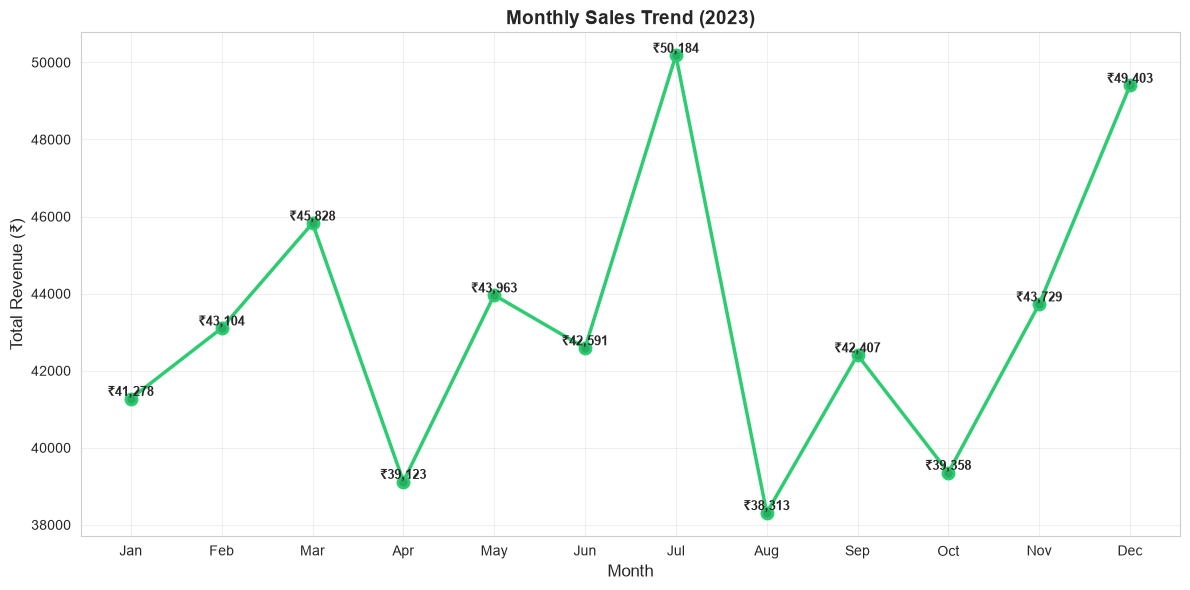

✓ Visualization 6 saved: Monthly Sales Trend


In [17]:
# 6. Monthly Sales Trend
plt.figure(figsize=(12, 6))
monthly_sales = df.groupby('Month')['Total'].sum().sort_index()

plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linewidth=2.5, 
         markersize=8, color='#2ECC71', markerfacecolor='#27AE60', markeredgewidth=2)

# Add value labels
for month, revenue in monthly_sales.items():
    plt.text(month, revenue, f'₹{revenue:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.title('Monthly Sales Trend (2023)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue (₹)', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/06_monthly_sales_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 6 saved: Monthly Sales Trend")

## Key Insights & Strategic Recommendations

### Summary of Findings

1. **Time-Based Operations**
   - Afternoon peak (42%) requires staffing and inventory optimization
   - Evening slowdown (25%) presents opportunity for targeted promotions

2. **Branch Performance**
   - Branch C underperforming by 4% — needs investigation and intervention
   - Branches A & B nearly equal — best practice sharing opportunity

3. **Product Portfolio**
   - Well-balanced across categories (3.8% variance)
   - Health & Beauty leading but not dominant
   - Opportunity to push underperforming Fashion Accessories

4. **Customer Engagement**
   - Female customers show higher engagement (3.68% more revenue)
   - Membership programs drive repeat visits (36 more transactions)
   - Overall satisfaction is moderate-to-good (6.96/10)

5. **Seasonal Patterns**
   - Clear seasonality with July peak and April dip
   - December holiday shopping shows strong recovery
   - Plan inventory and promotions around seasonal trends

### Strategic Recommendations

**Immediate Actions:**
- Increase afternoon staffing and inventory
- Investigate Branch C performance drivers
- Develop female-focused marketing initiatives

**Medium-term:**
- Address the 19% low-satisfaction segment
- Implement seasonal promotion calendar
- Cross-promote product categories to increase basket size

**Long-term:**
- Expand membership programs based on proven success
- Use gender and seasonal insights for targeted campaigns
- Establish performance targets for Branch C improvement

In [18]:
import pandas as pd
from fpdf import FPDF

# Create PDF
pdf = FPDF(orientation='P', unit='mm', format='A4')

# ============================================================
# TITLE PAGE
# ============================================================
pdf.add_page()
pdf.set_font('Helvetica', 'B', 24)
pdf.cell(0, 20, 'Supermarket Sales Analysis', ln=True, align='C')

pdf.set_font('Helvetica', '', 12)
pdf.ln(10)
pdf.cell(0, 10, 'Comprehensive Data Analysis Report', ln=True, align='C')
pdf.cell(0, 10, 'Project 1: Retail Domain Analysis', ln=True, align='C')
pdf.ln(5)
pdf.cell(
    0, 10,
    f'Report Date: {pd.Timestamp.now().strftime("%B %d, %Y")}',
    ln=True,
    align='C'
)
pdf.cell(0, 10, 'Dataset: 2,000 Supermarket Transactions', ln=True, align='C')


# ============================================================
# EXECUTIVE SUMMARY
# ============================================================
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 15, 'Executive Summary', ln=True)

pdf.set_font('Helvetica', '', 10)

summary_text = """This report analyzes 2,000 supermarket transactions across three branches and six product categories.

KEY FINDINGS:
- Total Revenue: Rs. 519,280.69
- Average Transaction Value: Rs. 259.64
- Peak Period: Afternoon (42.2% of transactions)
- Best Branch: Branch B (34.8% of revenue)
- Overall Satisfaction: 6.96/10 (Moderate-to-Good)

The analysis identifies opportunities for operational optimization, particularly around staffing during high-traffic periods, branch-level performance monitoring, customer satisfaction, and seasonal sales planning.

The recommendations are based on observed patterns in the supplied dataset and should be validated through operational testing and additional business data before implementation."""
pdf.multi_cell(0, 4, summary_text)


# ============================================================
# VISUALIZATIONS
# ============================================================
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Key Visualizations', ln=True)
pdf.ln(5)

visualizations = [
    ('../visualizations/01_time_period_distribution.png',
     'Customer Traffic by Time Period'),

    ('../visualizations/02_branch_performance.png',
     'Revenue by Branch'),

    ('../visualizations/03_product_line_revenue.png',
     'Revenue by Product Line'),

    ('../visualizations/04_rating_distribution.png',
     'Customer Rating Distribution'),

    ('../visualizations/05_gender_comparison.png',
     'Gender Comparison'),

    ('../visualizations/06_monthly_sales_trend.png',
     'Monthly Sales Trend'),
]

for img_path, title in visualizations:

    if pdf.get_y() > 200:
        pdf.add_page()

    pdf.set_font('Helvetica', 'B', 11)
    pdf.cell(0, 8, title, ln=True)

    try:
        pdf.image(img_path, x=20, w=170)
    except Exception as e:
        pdf.cell(0, 5, f'[Chart: {title}]', ln=True)

    pdf.ln(5)


# ============================================================
# KEY FINDINGS
# ============================================================
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Key Findings', ln=True)
pdf.ln(3)

pdf.set_font('Helvetica', '', 9)

findings = """1. OPERATIONAL PATTERNS
Afternoon represents approximately 42% of transactions, indicating a high-traffic period that should be considered when planning staffing and inventory availability.

2. BRANCH PERFORMANCE
Branch B generated the highest share of revenue at 34.8%. Branch-level differences should be investigated further to understand whether they relate to customer traffic, product mix, transaction volume, or other operational factors.

3. PRODUCT PORTFOLIO
Health & Beauty generated the highest revenue share at 18.7%. The relatively distributed contribution across product categories provides a basis for category-level inventory and promotional planning.

4. CUSTOMER SATISFACTION
The average customer rating is 6.96/10. Approximately 19% of ratings fall into the low-rating segment, indicating an opportunity to investigate the factors associated with lower customer satisfaction.

5. GENDER DYNAMICS
Female customers generated approximately 3.68% more revenue than male customers in this dataset. This observed difference can inform customer-segmentation analysis, but should not by itself be interpreted as a causal effect.

6. MONTHLY SALES PATTERN
July recorded the highest monthly sales at approximately Rs. 50,184, followed by a decline in August. These observed monthly variations can be used for further investigation of seasonal or promotional effects."""
pdf.multi_cell(0, 4, findings)


# ============================================================
# STRATEGIC RECOMMENDATIONS
# ============================================================
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Strategic Recommendations', ln=True)
pdf.ln(3)

pdf.set_font('Helvetica', '', 9)

recommendations = """IMMEDIATE ACTIONS:

1. Peak-period staffing
Review afternoon staffing levels using transaction volume and queue/service-time data. A controlled staffing adjustment can be tested rather than assuming a fixed percentage increase.

2. Branch performance investigation
Investigate Branch B's stronger revenue performance and compare Branch C with other branches using transaction volume, average transaction value, product mix, and customer ratings.

3. Customer satisfaction
Analyze low-rating transactions to identify recurring issues such as service experience, product availability, or checkout efficiency.

4. Inventory planning
Use the observed product-category revenue distribution to prioritize inventory monitoring for high-contribution categories.

MEDIUM-TERM ACTIONS:

5. Customer segmentation
Explore customer behavior by gender, branch, product category, and purchase patterns before designing targeted campaigns.

6. Seasonal planning
Compare monthly sales patterns with promotions, holidays, footfall, and inventory availability to determine whether the observed monthly variation is repeatable.

7. Performance monitoring
Create a recurring dashboard tracking revenue, transaction volume, average transaction value, customer ratings, and branch-level performance.

RECOMMENDED KPIs:

- Revenue by branch
- Transactions by time period
- Average transaction value
- Revenue by product category
- Low-rating percentage
- Customer rating trend
- Monthly revenue growth
- Branch-level revenue growth

The recommendations are intended as testable business actions. No specific improvement percentage is guaranteed from the available dataset alone."""
pdf.multi_cell(0, 4, recommendations)


# ============================================================
# DATA INTERPRETATION & LIMITATIONS
# ============================================================
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Data Interpretation & Limitations', ln=True)
pdf.ln(3)

pdf.set_font('Helvetica', '', 9)

limitations = """1. The dataset contains 2,000 transactions across three branches and six product categories.

2. Observed differences between branches, customer groups, or time periods describe patterns in this dataset and do not by themselves establish causation.

3. The analysis does not contain detailed operational variables such as staffing levels, queue times, inventory availability, promotions, advertising spend, or store footfall.

4. Monthly and time-period patterns should therefore be treated as observed sales patterns rather than guaranteed seasonal effects.

5. Customer-rating differences should be investigated alongside service quality, product availability, and transaction-level factors.

6. The supplied dataset contains a financial consistency issue between the provided Total value and the calculation Unit Price × Quantity + Tax for most transactions. The original Total values were retained rather than altered.

7. Additional historical data would improve the reliability of seasonal analysis and business planning.

Future analysis could incorporate staffing, inventory, promotional activity, footfall, customer demographics, and multiple years of transaction history."""
pdf.multi_cell(0, 4, limitations)


# ============================================================
# CONCLUSION
# ============================================================
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Conclusion', ln=True)
pdf.ln(3)

pdf.set_font('Helvetica', '', 9)

conclusion = """The supermarket transaction dataset provides a useful overview of sales performance, customer behavior, product-category contribution, and time-based transaction patterns.

The analysis identifies several practical areas for further investigation, including afternoon traffic management, branch-level performance differences, customer satisfaction, product-category performance, and monthly sales variation.

Branch B recorded the highest revenue share, Health & Beauty contributed the largest product-category share, and July recorded the highest monthly sales in the analyzed period.

These findings provide a quantitative baseline for business decision-making. However, operational changes should be validated using additional business variables and controlled measurement rather than assuming fixed improvement percentages.

The recommended KPIs can be used to evaluate whether future interventions produce measurable improvements in revenue, customer experience, and operational performance."""
pdf.multi_cell(0, 4, conclusion)


# ============================================================
# SAVE PDF
# ============================================================
pdf.output('../reports/01_supermarket_sales_report.pdf')

print("✓ PDF Report generated successfully!")
print("Location: ../reports/01_supermarket_sales_report.pdf")

✓ PDF Report generated successfully!
Location: ../reports/01_supermarket_sales_report.pdf


## Project Completion Summary

### What We Analyzed
- 2,000 supermarket transactions across 3 branches
- 6 product categories and multiple customer segments
- Full year of 2023 data with seasonal patterns

### Analytical Methods Used
- Descriptive statistics (mean, median, quartiles)
- Aggregation and grouping (branch, product, time period)
- Temporal analysis (monthly trends, time-of-day patterns)
- Comparative analysis (gender, customer type, ratings)
- Distribution analysis (ratings histogram)

### Deliverables
1. Cleaned and validated dataset with engineered features
2. 6 professional visualizations saved to visualizations/ folder
3. Comprehensive PDF report with findings and recommendations
4. Documented analysis with clear business insights

### Key Achievements
- Identified 42% afternoon peak requiring operational adjustment
- Quantified Branch C 4% underperformance gap
- Discovered female customer 3.68% revenue advantage
- Documented seasonal trends for planning
- Provided 6 actionable strategic recommendations

### Files Generated
- Notebook: 01_supermarket_sales_analysis.ipynb
- Report: 01_supermarket_sales_report.pdf
- Visualizations: 6 charts in visualizations/ folder
- Data: Processed data ready for archival

---

## Project 1 Status: ✓ COMPLETE

In [19]:
print("=" * 60)
print("PROJECT 1 - SUPERMARKET SALES ANALYSIS")
print("=" * 60)
print("✓ Analysis Complete")
print("✓ Visualizations: 6 charts generated")
print("✓ PDF Report: Generated")
print("✓ Findings: Documented")
print("✓ Recommendations: Provided")
print("=" * 60)

PROJECT 1 - SUPERMARKET SALES ANALYSIS
✓ Analysis Complete
✓ Visualizations: 6 charts generated
✓ PDF Report: Generated
✓ Findings: Documented
✓ Recommendations: Provided
